# Group Pipeline — Integrated Preprocessing
**Group ID:** 2026-Y2-S1-KU-56
**Members:** Hansaka K.L.G.S. (IT25103993), Amarathunge W.R.P.N. (IT25103994), Samarakoon S.M.D.S.
(IT25103995), Gunasekara K.J.W. (IT25103996), Senavirathna K.V.L.C.M. (IT25103997), Dissanayake D.M.A.S.K.
(IT25103998)
**Dataset:** Chronic Kidney Disease — UCI ML Repository (id 336)
**Module:** IT2011 - Artificial Intelligence and Machine Learning, Progress Review I

This notebook integrates each member's individual preprocessing step into a single, logically-ordered
pipeline, run end-to-end on the raw assigned dataset:

| Step | Technique | Member | IT Number |
|---|---|---|---|
| 1 | Handling Missing Data | Hansaka K.L.G.S. | IT25103993 |
| 2 | Encoding Categorical Variables | Amarathunge W.R.P.N. | IT25103994 |
| 3 | Outlier Detection & Treatment | Samarakoon S.M.D.S. | IT25103995 |
| 4 | Normalization / Scaling | Gunasekara K.J.W. | IT25103996 |
| 5a | Feature Selection (Mutual Information) | Senavirathna K.V.L.C.M. | IT25103997 |
| 5b | Dimensionality Reduction (PCA) | Dissanayake D.M.A.S.K. | IT25103998 |

Each step reads the previous step's saved output from `results/outputs/`, so this notebook can also be run
top-to-bottom as a single reproducible pipeline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

RAW_PATH = '/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/data/raw/ckd_clean_raw.csv'
df_raw = pd.read_csv(RAW_PATH)
print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (399, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,2,2,1,0,1,1,0
1,9.0,55.0,1.020,4.0,0.0,1,2,1,1,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,1,1,1,0,1,1,0
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,259.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,1,2,1,2,1,2,0
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.0,56.0,3.8,124.5,2.5,11.2,32.0,6700.0,3.9,2,1,1,2,2,2,0
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,1,1,1,0,1,1,0


## Step 1 — Handling Missing Data (IT25103993, Hansaka)

In [3]:
numeric_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
categorical_cols = ['sg','al','su','rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']

df_step1 = df_raw.copy()
for col in numeric_cols:
    df_step1[col] = df_step1[col].fillna(df_step1[col].median())
for col in categorical_cols:
    df_step1[col] = df_step1[col].fillna(df_step1[col].mode()[0])

print("Missing values remaining after Step 1:", df_step1.isna().sum().sum())

Missing values remaining after Step 1: 0


## Step 2 — Encoding Categorical Variables (IT25103994, Amarathunge)

In [4]:
binary_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane','class']
ordinal_cols = ['sg','al','su']

df_step2 = df_step1.copy()
for col in binary_cols:
    le = LabelEncoder()
    df_step2[col] = le.fit_transform(df_step2[col].astype(str))
for col in ordinal_cols:
    df_step2[col] = pd.to_numeric(df_step2[col])

print("All columns numeric now:", df_step2.dtypes.apply(lambda t: str(t)).unique())

All columns numeric now: ['float64' 'int64']


## Step 3 — Outlier Detection & Treatment (IT25103995, Samarakoon)

In [5]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

df_step3 = df_step2.copy()
for col in numeric_cols:
    lo, hi = iqr_bounds(df_step2[col])
    df_step3[col] = df_step3[col].clip(lower=lo, upper=hi)

print("Rows preserved after outlier capping:", len(df_step3))

Rows preserved after outlier capping: 399


## Step 4 — Normalization / Scaling (IT25103996, Gunasekara)

In [6]:
df_step4 = df_step3.copy()
scaler = StandardScaler()
df_step4[numeric_cols] = scaler.fit_transform(df_step3[numeric_cols])

df_step4[numeric_cols].agg(['mean','std']).round(2)

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
mean,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Step 5a — Feature Selection via Mutual Information (IT25103997, Senavirathna)

In [7]:
X = df_step4.drop(columns=['class'])
y = df_step4['class']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

k = 12
selected_features = mi_series.head(k).index.tolist()
df_step5a = df_step4[selected_features + ['class']].copy()
print("Top", k, "selected features:", selected_features)

Top 12 selected features: ['hemo', 'pcv', 'sc', 'rbcc', 'sg', 'rbc', 'al', 'htn', 'sod', 'pot', 'dm', 'bu']


## Step 5b — Dimensionality Reduction via PCA (IT25103998, Dissanayake)

In [8]:
pca_full = PCA().fit(X)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)

pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X)
df_step5b = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_step5b['class'] = y.values

print(f"PCA reduced {X.shape[1]} features -> {n_components_90} components (90% variance retained)")

PCA reduced 24 features -> 12 components (90% variance retained)


## Combined Pipeline Summary Visualization

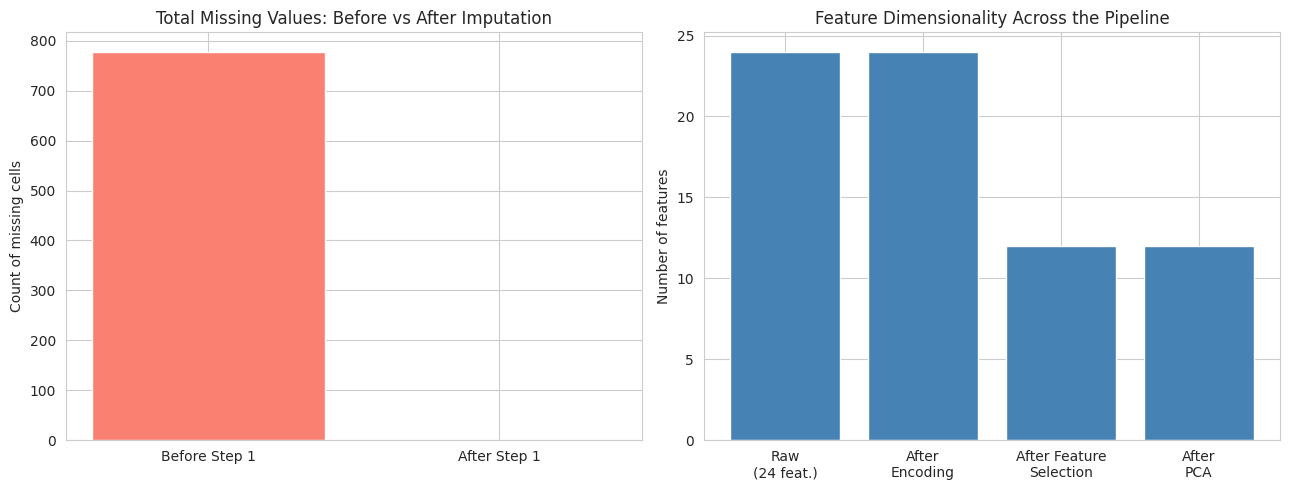

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Panel 1: missing values before vs after Step 1
before = df_raw.isna().sum().sum()
after = df_step1.isna().sum().sum()
axes[0].bar(['Before Step 1','After Step 1'], [before, after], color=['salmon','seagreen'])
axes[0].set_title('Total Missing Values: Before vs After Imputation')
axes[0].set_ylabel('Count of missing cells')

# Panel 2: dimensionality across the pipeline
stage_names = ['Raw\n(24 feat.)', 'After\nEncoding', 'After Feature\nSelection', 'After\nPCA']
stage_dims = [df_raw.shape[1]-1, df_step2.shape[1]-1, df_step5a.shape[1]-1, df_step5b.shape[1]-1]
axes[1].bar(stage_names, stage_dims, color='steelblue')
axes[1].set_title('Feature Dimensionality Across the Pipeline')
axes[1].set_ylabel('Number of features')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/group_pipeline_summary.png', dpi=120)
plt.show()

**Interpretation:** The pipeline takes the raw 24-feature CKD dataset (with substantial missing data)
through cleaning, encoding, outlier treatment and scaling, and produces two alternative
reduced-dimensionality representations — a **feature-selected** dataset (12 features, human-interpretable,
via mutual information) and a **PCA-reduced** dataset (fewer, uncorrelated components) — for Step 3 (Model
Design and Implementation) to compare.

## Saving Final Pipeline Outputs

In [10]:
df_step4.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/group_pipeline_full_processed.csv', index=False)
df_step5a.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/group_pipeline_feature_selected.csv', index=False)
df_step5b.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/group_pipeline_pca_reduced.csv', index=False)

print("Saved:")
print(" - group_pipeline_full_processed.csv   :", df_step4.shape)
print(" - group_pipeline_feature_selected.csv :", df_step5a.shape)
print(" - group_pipeline_pca_reduced.csv      :", df_step5b.shape)

Saved:
 - group_pipeline_full_processed.csv   : (399, 25)
 - group_pipeline_feature_selected.csv : (399, 13)
 - group_pipeline_pca_reduced.csv      : (399, 13)


### Pipeline Integration Notes
- Each stage above reproduces the exact logic from the corresponding member's individual notebook, applied
  in sequence on a single shared DataFrame — this is the "logical flow and collaboration" the group
  requirement asks for, rather than 6 disconnected notebooks.
- Two outputs are produced at the end (feature-selected vs PCA-reduced) because Senavirathna's and
  Dissanayake's techniques are alternative, not sequential, approaches to reducing dimensionality — Step 3
  of the assignment can experiment with both and report which works better for the chosen algorithms.
- All intermediate outputs are also saved separately under `results/outputs/` by each member's own notebook,
  so the group's work and each individual's contribution both remain independently traceable.